## 1. Mount Google Drive & Salin Dataset ke Lokal

In [ ]:
import os
import shutil
from google.colab import drive
drive.mount('/gdrive')

src_train = '/gdrive/MyDrive/klasifiksi/archive (1)/Banana Ripeness Classification Dataset/train'
src_valid = '/gdrive/MyDrive/klasifiksi/archive (1)/Banana Ripeness Classification Dataset/valid'
src_test  = '/gdrive/MyDrive/klasifiksi/archive (1)/Banana Ripeness Classification Dataset/test'

dst_train = '/content/train_local'
dst_valid = '/content/valid_local'
dst_test  = '/content/test_local'

print("🔄 Memulai penyalinan data dari Drive ke Lokal...")
for d in [dst_train, dst_valid, dst_test]:
    if os.path.exists(d):
        shutil.rmtree(d)

try:
    shutil.copytree(src_train, dst_train)
    shutil.copytree(src_valid, dst_valid)
    shutil.copytree(src_test, dst_test)
    print("✅ SELESAI! Data berhasil disalin ke /content/train_local, /content/valid_local, dan /content/test_local")
except FileNotFoundError as e:
    print(f"❌ ERROR: Folder tidak ditemukan: {e}")
    print("Cek kembali nama folder di Google Drive Anda (huruf besar/kecil/spasi).")

os.chdir('/content')
print("Direktori kerja sekarang:", os.getcwd())


Mounted at /gdrive
🔄 Memulai penyalinan data dari Drive ke Lokal...
✅ SELESAI! Data berhasil disalin ke /content/train_local, /content/valid_local, dan /content/test_local
Direktori kerja sekarang: /content


## 2. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU tersedia: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 3. Eksplorasi Dataset
Cek jumlah kelas (folder) dan jumlah gambar pada masing-masing kelas di data train.

In [ ]:
class_names = sorted(os.listdir(dst_train))
print("Jumlah kelas:", len(class_names))
print("Nama kelas:", class_names)

print("\nJumlah gambar per kelas (train):")
for c in class_names:
    jumlah = len(os.listdir(os.path.join(dst_train, c)))
    print(f"  - {c}: {jumlah} gambar")

print("\nJumlah gambar per kelas (valid):")
for c in sorted(os.listdir(dst_valid)):
    jumlah = len(os.listdir(os.path.join(dst_valid, c)))
    print(f"  - {c}: {jumlah} gambar")

print("\nJumlah gambar per kelas (test):")
for c in sorted(os.listdir(dst_test)):
    jumlah = len(os.listdir(os.path.join(dst_test, c)))
    print(f"  - {c}: {jumlah} gambar")


Jumlah kelas: 4
Nama kelas: ['overripe', 'ripe', 'rotten', 'unripe']

Jumlah gambar per kelas (train):
  - overripe: 2349 gambar
  - ripe: 3522 gambar
  - rotten: 4020 gambar
  - unripe: 1902 gambar

Jumlah gambar per kelas (valid):
  - overripe: 229 gambar
  - ripe: 339 gambar
  - rotten: 388 gambar
  - unripe: 167 gambar

Jumlah gambar per kelas (test):
  - overripe: 113 gambar
  - ripe: 154 gambar
  - rotten: 185 gambar
  - unripe: 110 gambar


/tmp/ipykernel_538/2248911585.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="YlGn")


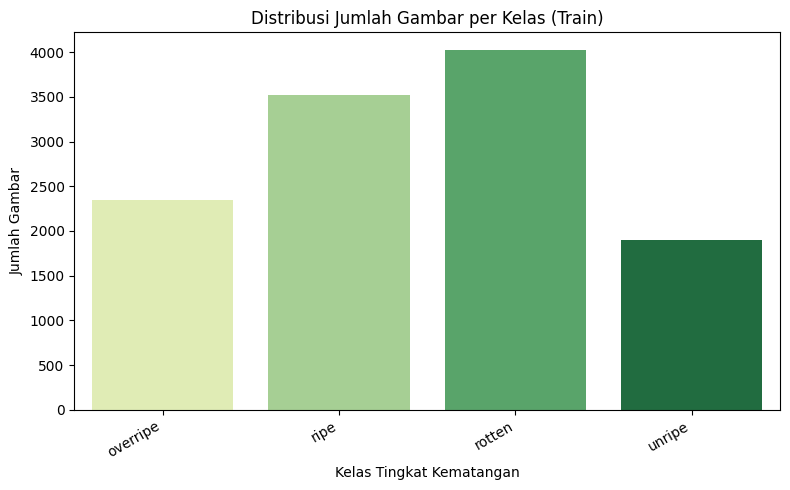

In [ ]:
# Visualisasi jumlah gambar per kelas (train)
counts = [len(os.listdir(os.path.join(dst_train, c))) for c in class_names]

plt.figure(figsize=(8, 5))
sns.barplot(x=class_names, y=counts, palette="YlGn")
plt.title("Distribusi Jumlah Gambar per Kelas (Train)")
plt.xlabel("Kelas Tingkat Kematangan")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


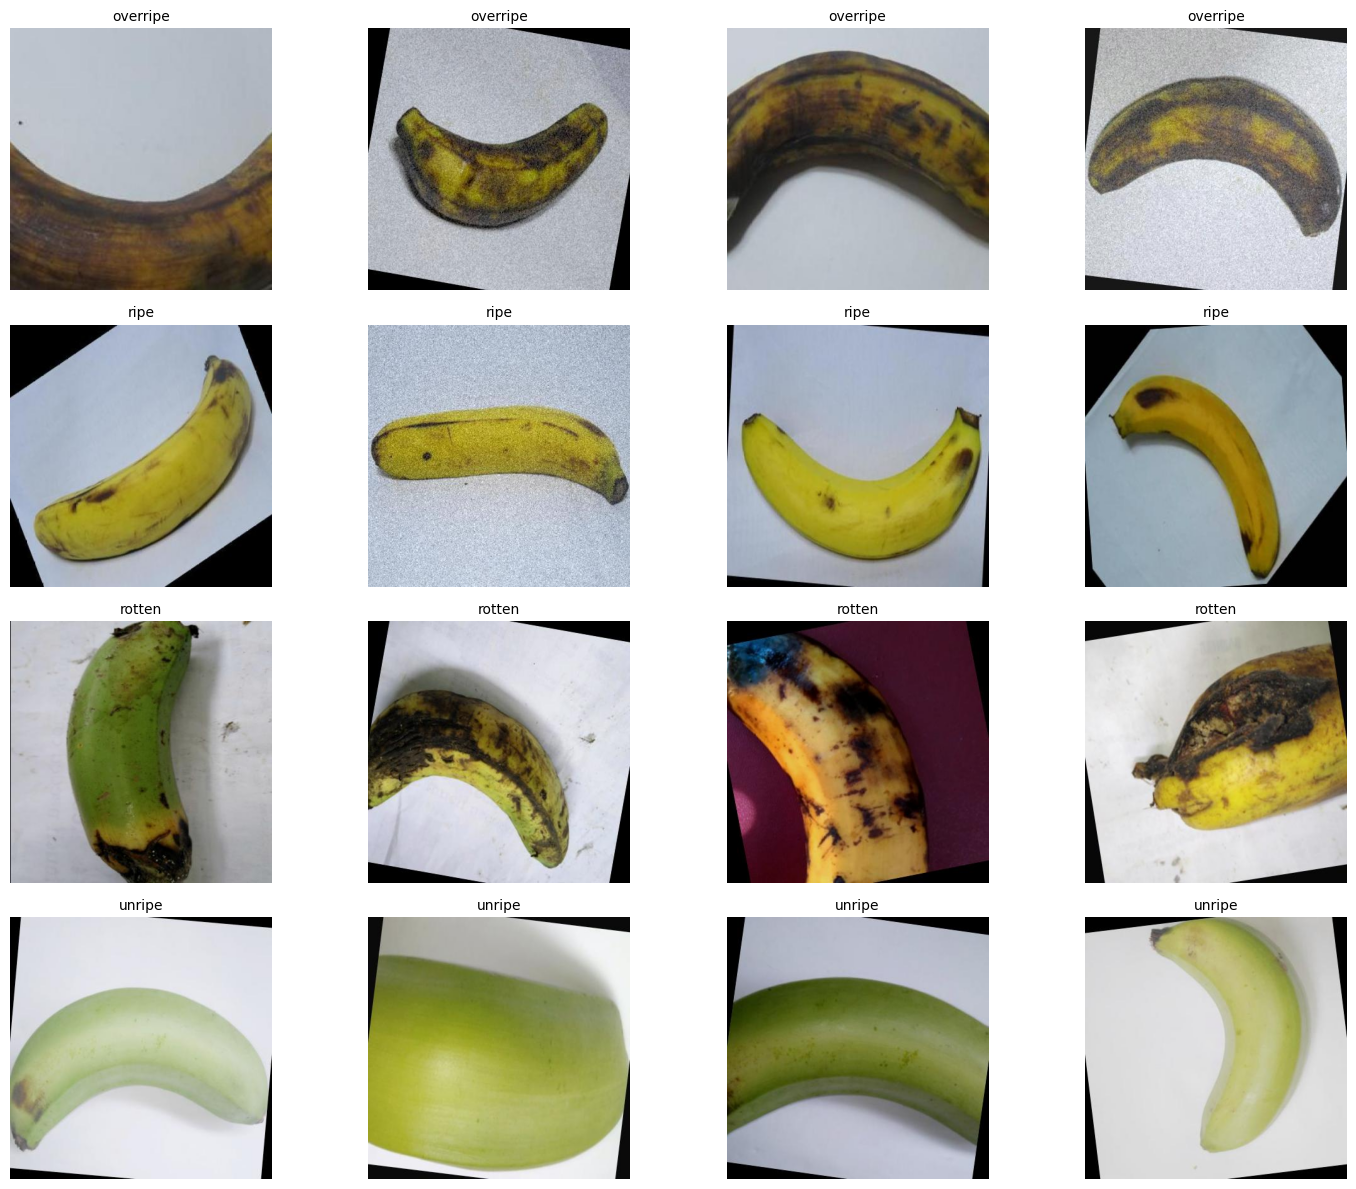

In [ ]:
# Menampilkan beberapa contoh gambar dari setiap kelas
import random
from tensorflow.keras.preprocessing import image as kimage

plt.figure(figsize=(15, 3 * len(class_names)))
for i, c in enumerate(class_names):
    folder = os.path.join(dst_train, c)
    sample_files = random.sample(os.listdir(folder), min(4, len(os.listdir(folder))))
    for j, f in enumerate(sample_files):
        img = kimage.load_img(os.path.join(folder, f))
        ax = plt.subplot(len(class_names), 4, i * 4 + j + 1)
        plt.imshow(img)
        plt.title(c, fontsize=10)
        plt.axis('off')
plt.tight_layout()
plt.show()


## 4. Persiapan Data (Data Generator & Augmentasi)


In [ ]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

valid_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dst_train,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_directory(
    dst_valid,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    dst_test,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_generator.num_classes
class_indices = train_generator.class_indices
labels_map = {v: k for k, v in class_indices.items()}

print("Jumlah kelas:", num_classes)
print("Mapping kelas:", class_indices)


Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.
Jumlah kelas: 4
Mapping kelas: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


## 5. Membangun Arsitektur CNN
Arsitektur CNN sederhana dengan beberapa blok Convolution + Pooling, diikuti Dense layer untuk klasifikasi akhir.

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     5,308,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,732,420 (21.87 MB)

 Trainable params: 5,731,460 (21.86 MB)

 Non-trainable params: 960 (3.75 KB)

## 6. Callback Training
Menggunakan `EarlyStopping` (menghentikan training bila tidak ada peningkatan), `ModelCheckpoint` (menyimpan model terbaik), dan `ReduceLROnPlateau` (menurunkan learning rate otomatis).

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'model_terbaik_pisang.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

EPOCHS = 30

history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.5960 - loss: 2.4535
Epoch 1: val_accuracy improved from None to 0.74978, saving model to model_terbaik_pisang.h5



Epoch 1: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 128s 311ms/step - accuracy: 0.6600 - loss: 1.5546 - val_accuracy: 0.7498 - val_loss: 0.7312 - learning_rate: 0.0010
Epoch 2/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.7507 - loss: 0.7669
Epoch 2: val_accuracy improved from 0.74978 to 0.83526, saving model to model_terbaik_pisang.h5



Epoch 2: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 101s 273ms/step - accuracy: 0.7747 - loss: 0.6785 - val_accuracy: 0.8353 - val_loss: 0.4308 - learning_rate: 0.0010
Epoch 3/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.8050 - loss: 0.5530
Epoch 3: val_accuracy did not improve from 0.83526
369/369 ━━━━━━━━━━━━━━━━━━━━ 101s 273ms/step - accuracy: 0.8219 - loss: 0.5172 - val_accuracy: 0.8192 - val_loss: 0.4652 - learning_rate: 0.0010
Epoch 4/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.8489 - loss: 0.4516
Epoch 4: val_accuracy improved from 0.83526 to 0.86554, saving model to model_terbaik_pisang.h5



Epoch 4: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 100s 271ms/step - accuracy: 0.8557 - loss: 0.4348 - val_accuracy: 0.8655 - val_loss: 0.3784 - learning_rate: 0.0010
Epoch 5/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 265ms/step - accuracy: 0.8701 - loss: 0.3924
Epoch 5: val_accuracy did not improve from 0.86554
369/369 ━━━━━━━━━━━━━━━━━━━━ 100s 270ms/step - accuracy: 0.8625 - loss: 0.4051 - val_accuracy: 0.4212 - val_loss: 2.2155 - learning_rate: 0.0010
Epoch 6/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.8683 - loss: 0.3797
Epoch 6: val_accuracy did not improve from 0.86554
369/369 ━━━━━━━━━━━━━━━━━━━━ 103s 280ms/step - accuracy: 0.8761 - loss: 0.3620 - val_accuracy: 0.8370 - val_loss: 0.3766 - learning_rate: 0.0010
Epoch 7/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.8892 - loss: 0.3411
Epoch 7: val_accuracy improved from 0.86554 to 0.92965, saving model to model_terbaik_pisang.h5



Epoch 7: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 103s 278ms/step - accuracy: 0.8886 - loss: 0.3418 - val_accuracy: 0.9297 - val_loss: 0.2404 - learning_rate: 0.0010
Epoch 8/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.8991 - loss: 0.3221
Epoch 8: val_accuracy did not improve from 0.92965
369/369 ━━━━━━━━━━━━━━━━━━━━ 101s 274ms/step - accuracy: 0.8986 - loss: 0.3197 - val_accuracy: 0.7231 - val_loss: 0.8512 - learning_rate: 0.0010
Epoch 9/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.9052 - loss: 0.3057
Epoch 9: val_accuracy did not improve from 0.92965
369/369 ━━━━━━━━━━━━━━━━━━━━ 101s 275ms/step - accuracy: 0.9058 - loss: 0.3013 - val_accuracy: 0.8673 - val_loss: 0.3951 - learning_rate: 0.0010
Epoch 10/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step - accuracy: 0.9120 - loss: 0.3039
Epoch 10: val_accuracy did not improve from 0.92965
369/369 ━━━━━━━━━━━━━━━━━━━━ 103s 279ms/step - accuracy: 0.9144 - loss: 0.2860 - val_ac

...


Epoch 19: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 98s 266ms/step - accuracy: 0.9546 - loss: 0.1508 - val_accuracy: 0.9662 - val_loss: 0.1470 - learning_rate: 5.0000e-04
Epoch 20/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - accuracy: 0.9575 - loss: 0.1405
Epoch 20: val_accuracy did not improve from 0.96616
369/369 ━━━━━━━━━━━━━━━━━━━━ 97s 263ms/step - accuracy: 0.9554 - loss: 0.1462 - val_accuracy: 0.9332 - val_loss: 0.1972 - learning_rate: 5.0000e-04
Epoch 21/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.9592 - loss: 0.1331
Epoch 21: val_accuracy did not improve from 0.96616
369/369 ━━━━━━━━━━━━━━━━━━━━ 96s 259ms/step - accuracy: 0.9588 - loss: 0.1357 - val_accuracy: 0.8557 - val_loss: 0.3792 - learning_rate: 5.0000e-04
Epoch 22/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9620 - loss: 0.1122
Epoch 22: val_accuracy improved from 0.96616 to 0.97240, saving model to model_terbaik_pisang.h5



Epoch 22: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 98s 266ms/step - accuracy: 0.9629 - loss: 0.1183 - val_accuracy: 0.9724 - val_loss: 0.0867 - learning_rate: 5.0000e-04
Epoch 23/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.9634 - loss: 0.1168
Epoch 23: val_accuracy did not improve from 0.97240
369/369 ━━━━━━━━━━━━━━━━━━━━ 98s 265ms/step - accuracy: 0.9628 - loss: 0.1202 - val_accuracy: 0.9421 - val_loss: 0.1837 - learning_rate: 5.0000e-04
Epoch 24/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.9659 - loss: 0.1156
Epoch 24: val_accuracy did not improve from 0.97240
369/369 ━━━━━━━━━━━━━━━━━━━━ 96s 259ms/step - accuracy: 0.9633 - loss: 0.1223 - val_accuracy: 0.9679 - val_loss: 0.1150 - learning_rate: 5.0000e-04
Epoch 25/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.9698 - loss: 0.1048
Epoch 25: val_accuracy did not improve from 0.97240
369/369 ━━━━━━━━━━━━━━━━━━━━ 147s 273ms/step - accuracy: 0.9686 - loss: 0


Epoch 27: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 105s 285ms/step - accuracy: 0.9724 - loss: 0.0896 - val_accuracy: 0.9768 - val_loss: 0.0807 - learning_rate: 2.5000e-04
Epoch 28/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step - accuracy: 0.9737 - loss: 0.0801
Epoch 28: val_accuracy did not improve from 0.97685
369/369 ━━━━━━━━━━━━━━━━━━━━ 100s 271ms/step - accuracy: 0.9731 - loss: 0.0825 - val_accuracy: 0.9733 - val_loss: 0.0830 - learning_rate: 2.5000e-04
Epoch 29/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.9752 - loss: 0.0761
Epoch 29: val_accuracy improved from 0.97685 to 0.97952, saving model to model_terbaik_pisang.h5



Epoch 29: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 102s 276ms/step - accuracy: 0.9754 - loss: 0.0751 - val_accuracy: 0.9795 - val_loss: 0.0642 - learning_rate: 2.5000e-04
Epoch 30/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.9756 - loss: 0.0781
Epoch 30: val_accuracy improved from 0.97952 to 0.98219, saving model to model_terbaik_pisang.h5



Epoch 30: finished saving model to model_terbaik_pisang.h5
369/369 ━━━━━━━━━━━━━━━━━━━━ 99s 269ms/step - accuracy: 0.9763 - loss: 0.0771 - val_accuracy: 0.9822 - val_loss: 0.0598 - learning_rate: 2.5000e-04


## 7. Visualisasi Hasil Training (Akurasi & Loss)

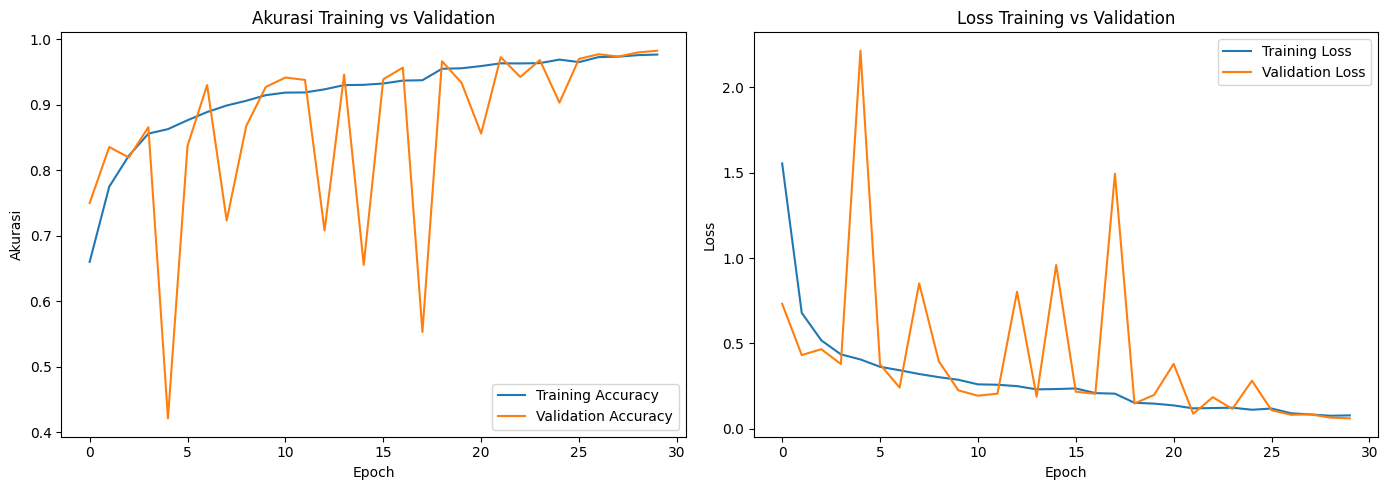

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Akurasi Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss Training vs Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()


## 8. Evaluasi Model pada Data Test

In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Akurasi pada data Test: {test_acc*100:.2f}%")
print(f"Loss pada data Test: {test_loss:.4f}")


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step - accuracy: 0.9804 - loss: 0.0480
Akurasi pada data Test: 98.04%
Loss pada data Test: 0.0480


In [ ]:
# Prediksi seluruh data test untuk confusion matrix & classification report
test_generator.reset()
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

target_names = [labels_map[i] for i in range(num_classes)]

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=target_names))


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step
Classification Report:

              precision    recall  f1-score   support

    overripe       0.98      0.96      0.97       113
        ripe       0.97      1.00      0.98       154
      rotten       0.99      0.96      0.98       185
      unripe       0.97      1.00      0.99       110

    accuracy                           0.98       562
   macro avg       0.98      0.98      0.98       562
weighted avg       0.98      0.98      0.98       562



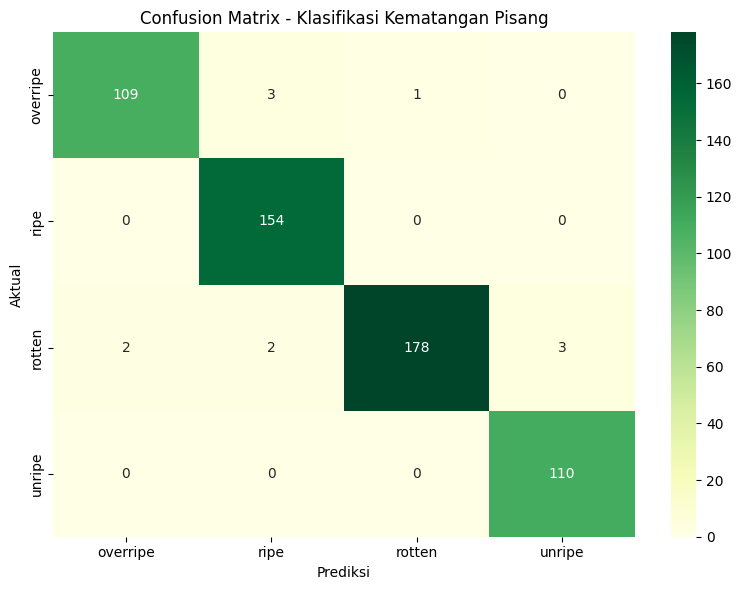

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Klasifikasi Kematangan Pisang')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()


## 9. Prediksi & Visualisasi Contoh Gambar dari Data Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step


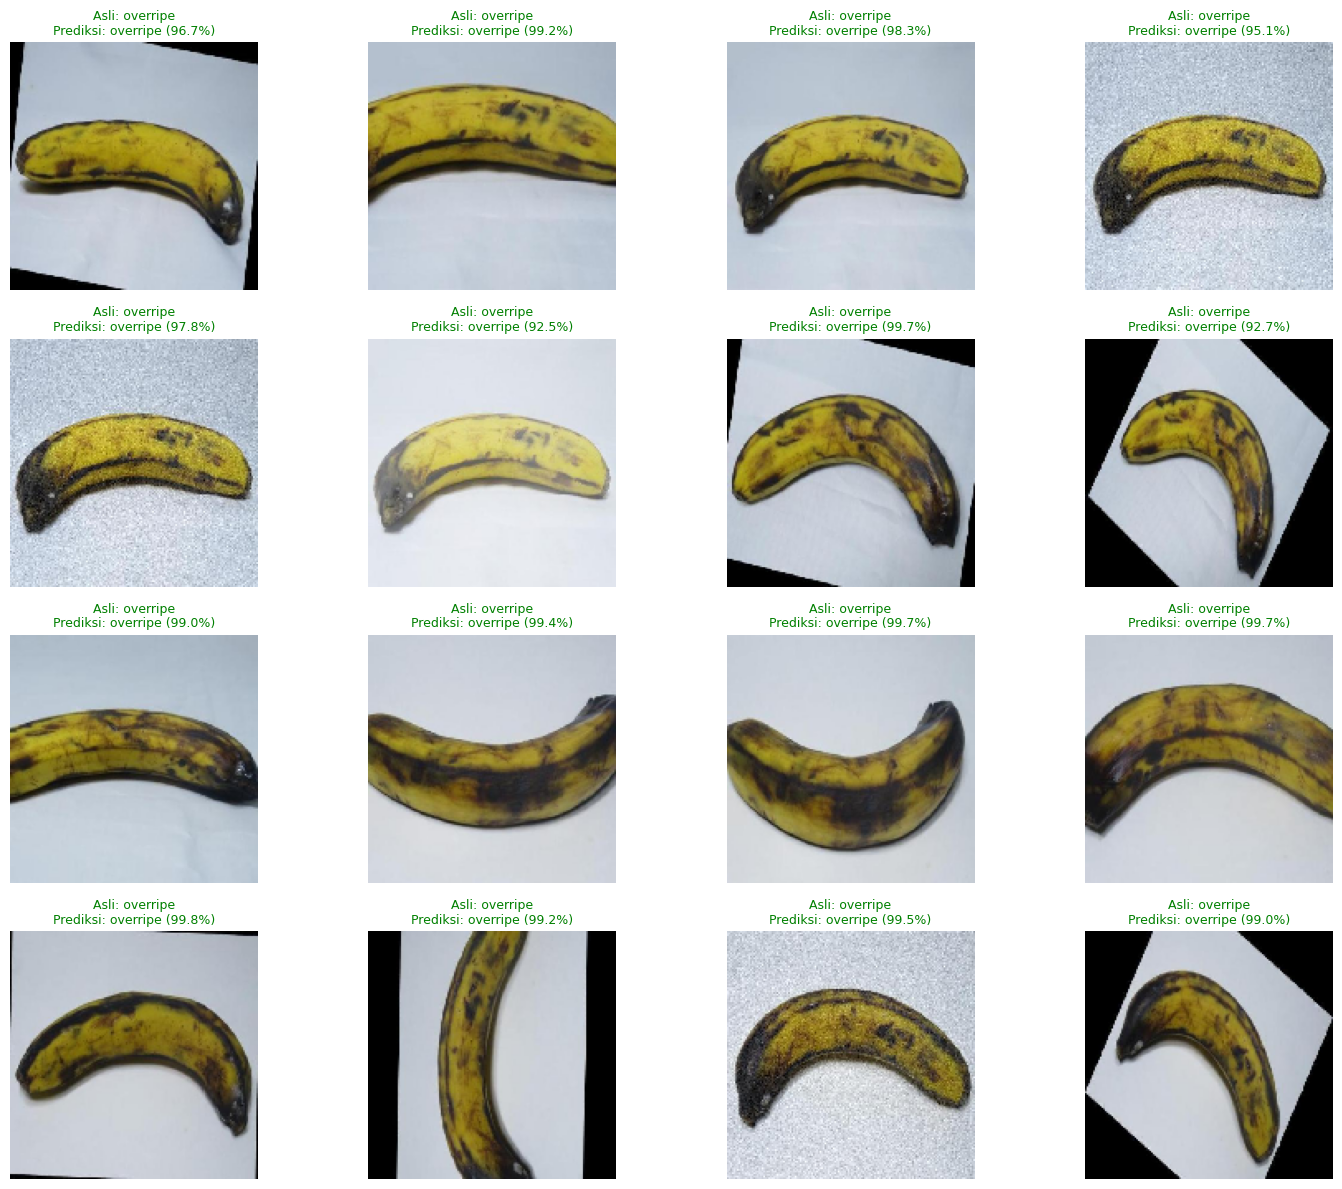

In [ ]:
# Ambil satu batch dari test generator untuk divisualisasikan
test_generator.reset()
images, labels = next(test_generator)
preds = model.predict(images)

plt.figure(figsize=(15, 12))
n_show = min(16, len(images))
for i in range(n_show):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i])
    true_label = labels_map[np.argmax(labels[i])]
    pred_label = labels_map[np.argmax(preds[i])]
    confidence = np.max(preds[i]) * 100
    color = 'green' if true_label == pred_label else 'red'
    plt.title(f"Asli: {true_label}\nPrediksi: {pred_label} ({confidence:.1f}%)",
              color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()


## 10. Menyimpan Model Akhir
Model final disimpan ke lokal Colab dan juga bisa disalin kembali ke Google Drive agar tidak hilang saat sesi Colab berakhir.

In [ ]:
model.save('model_kematangan_pisang_final.h5')
print("✅ Model disimpan sebagai 'model_kematangan_pisang_final.h5'")

# (Opsional) salin model ke Google Drive
drive_output_dir = '/gdrive/MyDrive/klasifiksi/model_output'
os.makedirs(drive_output_dir, exist_ok=True)
shutil.copy('model_kematangan_pisang_final.h5', drive_output_dir)
shutil.copy('model_terbaik_pisang.h5', drive_output_dir)
print(f"✅ Model juga disalin ke Google Drive: {drive_output_dir}")


✅ Model disimpan sebagai 'model_kematangan_pisang_final.h5'
✅ Model juga disalin ke Google Drive: /gdrive/MyDrive/klasifiksi/model_output


## 11. Fungsi Prediksi Gambar Baru
Fungsi ini bisa dipakai untuk menguji model dengan satu gambar pisang baru (misalnya hasil foto/upload).

In [ ]:
def prediksi_kematangan(path_gambar, model=model):
    img = kimage.load_img(path_gambar, target_size=IMG_SIZE)
    img_array = kimage.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    kelas_prediksi = labels_map[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.title(f"Prediksi: {kelas_prediksi} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    return kelas_prediksi, confidence

# Contoh penggunaan (ganti dengan path gambar milik Anda):
# prediksi_kematangan('/content/test_local/NAMA_KELAS/nama_file.jpg')
